In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset/TubacooCaterpillar/TubacooCaterpillar_168.jpg
/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset/TubacooCaterpillar/TubacooCaterpillar_1.jpg
/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset/TubacooCaterpillar/TubacooCaterpillar_400.jpg
/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset/TubacooCaterpillar/TubacooCaterpillar_178.jpg
/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset/TubacooCaterpillar/TubacooCaterpillar_200.jpg
/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset/TubacooCaterpillar/TubacooCaterpillar_235.jpg
/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset/TubacooCaterpillar/TubacooCaterpillar_427.jpg
/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset/TubacooCaterpillar/TubacooCaterpillar_389.jpg
/kaggle/input/datasets/riyaakter09/cse475-

# CSE 475 - Assignment 01
## Group Information

| Field | Details |
|-------------------------|-------------------------------------|
| **Group ID** | Group H |
| **Student 1 Name** | Benazir Meem |
| **Student 1 ID** | 2022-3-60-169 |
| **Student 2 Name** | Asifa Akter Liya  |
| **Student 2 ID** | 2022-3-60-186|
| **Student 3 Name** | Riya Akter |
| **Student 3 ID** | 2022-3-60-176|
| **Student 4 Name** | Sadia Afrin |
| **Student 4 ID** | 2022-2-60-088 |
| **Notebook Type** | CNN Models |
| **Dataset Source Name** | Eggplant Leaf Disease Classification Dataset |
| **Dataset Source Link** | https://data.mendeley.com/datasets/pvsv534ccg/1 |
| **Kaggle Dataset Path** |/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset |
| **Submission Date** | 31 March 2026 |



 ## 1.Global Configuration

In [2]:
# ==========================================
# 1. GLOBAL CONFIGURATION
# ==========================================
import os
import random
import torch
import numpy as np

# Hyperparameters
EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

DATASET_DIR = '/kaggle/input/datasets/riyaakter09/cse475-grouph-dataset/Eggplant Dataset'
CHECKPOINT_DIR = './checkpoints'

# Reproducibility constraints
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f"Global Configuration Set. Seed={SEED}")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)


Global Configuration Set. Seed=42


## 2.Setup & Imports

In [3]:
# Install required packages
!pip install -q albumentations

import albumentations as A
from albumentations.pytorch import ToTensorV2
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from torchvision import models
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import time
import copy
from tqdm.notebook import tqdm
import warnings

warnings.filterwarnings('ignore')

# Confirm GPU Availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
print(f"PyTorch Version: {torch.__version__}")


Using device: cuda
GPU Name: Tesla T4
PyTorch Version: 2.10.0+cu128


## 3.Exploratory Data Analysis (EDA)

Class Counts -> Highly Imbalanced Dataset!
 - TubacooCaterpillar: 452
 - Cercospora: 628
 - VerticilliumWilt: 163
 - FleaBeetles: 84
 - HaddaBeetles: 530
 - Curl: 284
 - Healthy: 188
 - MagnesiumDeficiency: 50
 - PhomopsisBlight: 218
 - TMV: 356
 - LeafhopperJassids: 38


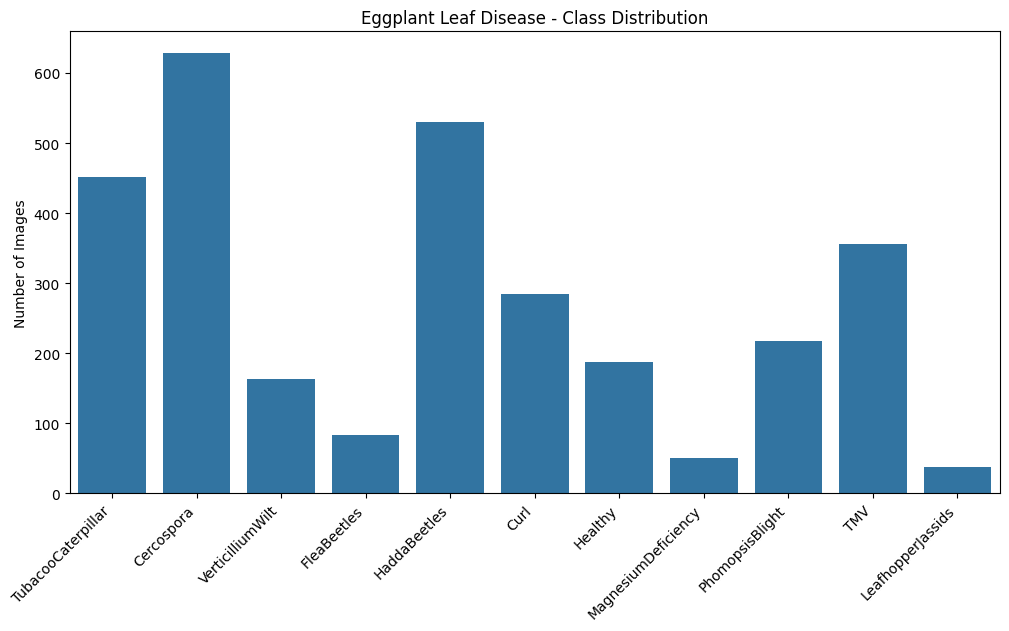

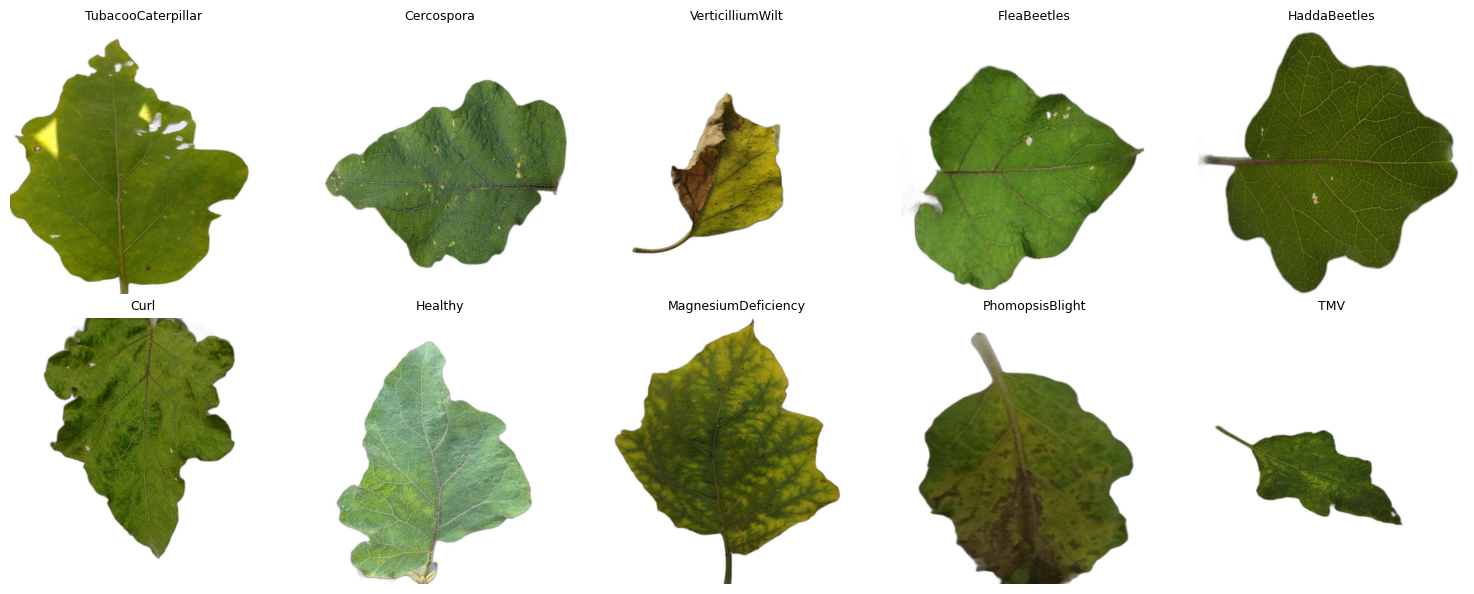

In [4]:
from pathlib import Path
from PIL import Image

def perform_eda(data_dir):
    data_path = Path(data_dir)
    if not data_path.exists():
        print(f"Dataset path {data_dir} does not exist.")
        return []
    
    classes = [d.name for d in data_path.iterdir() if d.is_dir()]
    class_counts = {c: len(list((data_path / c).glob('*.*'))) for c in classes}
    
    print("Class Counts -> Highly Imbalanced Dataset!")
    for c, count in class_counts.items(): 
        print(f" - {c}: {count}")
    
    # Plot Class Distribution
    plt.figure(figsize=(12, 6))
    sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
    plt.xticks(rotation=45, ha='right')
    plt.title('Eggplant Leaf Disease - Class Distribution')
    plt.ylabel('Number of Images')
    plt.show()
    
    # Display Sample Images
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for idx, c in enumerate(classes[:10]):
        sample_img_path = list((data_path / c).glob('*.*'))[0]
        img = Image.open(sample_img_path)
        axes[idx].imshow(img)
        axes[idx].set_title(c, fontsize=9)
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()

    return list(class_counts.keys())

class_names = perform_eda(DATASET_DIR)


## 4.Data Preprocessing & Augmentation
*Utilizing CutMix (implemented in Training step via PyTorch logic to meet advanced augmentation requirements), Resize/Crop, Horizontal Flip, and Standard Normalization.*

In [5]:
class AugmentedDataset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x_np = np.array(x)
            augmented = self.transform(image=x_np)
            x = augmented['image']
        return x, y
        
    def __len__(self):
        return len(self.subset)

# Define Transforms
train_transform = A.Compose([
    A.Resize(256, 256),
    A.RandomCrop(224, 224),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

def prepare_dataloaders(data_dir):
    try:
        full_dataset = ImageFolder(root=data_dir)
    except FileNotFoundError:
        print("Dataset not found during loader prep. Check DATASET_DIR path.")
        return None, None, None, []

    # 80-10-10 Split Strategy
    train_size = int(0.8 * len(full_dataset))
    val_size = int(0.1 * len(full_dataset))
    test_size = len(full_dataset) - train_size - val_size
    
    train_subset, val_subset, test_subset = random_split(
        full_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    
    # -------------------------------------------------------------
    # Handle Highly Imbalanced Dataset using WeightedRandomSampler
    # -------------------------------------------------------------
    train_indices = train_subset.indices
    train_targets = [full_dataset.targets[i] for i in train_indices]
    class_sample_counts = np.bincount(train_targets)
    weights = 1. / class_sample_counts
    samples_weights = torch.from_numpy(weights[train_targets]).double()
    sampler = torch.utils.data.WeightedRandomSampler(samples_weights, len(samples_weights))
    
    train_loader = DataLoader(AugmentedDataset(train_subset, transform=train_transform), batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
    val_loader = DataLoader(AugmentedDataset(val_subset, transform=val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(AugmentedDataset(test_subset, transform=val_test_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    return train_loader, val_loader, test_loader, full_dataset.classes

train_loader, val_loader, test_loader, class_names = prepare_dataloaders(DATASET_DIR)
print("====== DATASET SPLIT SUCCESS ======")
print(f"Total Classes: {len(class_names)}")
print(f"Training Batches: {len(train_loader)} (approx {len(train_loader.dataset)} images)")
print(f"Validation Batches: {len(val_loader)} (approx {len(val_loader.dataset)} images)")
print(f"Testing Batches: {len(test_loader)} (approx {len(test_loader.dataset)} images)")

for images, labels in train_loader:
    print(f"\nBatch Image Shape: {images.shape}") # Should be [32, 3, 224, 224] mapped as [Batch, Channels, Height, Width]
    print(f"Batch Label Shape: {labels.shape}")
    break



====== DATASET SPLIT SUCCESS ======
Total Classes: 11
Training Batches: 75 (approx 2392 images)
Validation Batches: 10 (approx 299 images)
Testing Batches: 10 (approx 300 images)

Batch Image Shape: torch.Size([32, 3, 224, 224])
Batch Label Shape: torch.Size([32])


## 5.Training Infrastructure
Defining Loss function, optimizer, Cosine LR Scheduling, and Early Stopping. CutMix is heavily embedded straight into the training loop.

In [6]:
# CutMix Core Logic
def cutmix_data(x, y, alpha=1.0):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    
    W = x.size()[2]
    H = x.size()[3]
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)

    cx = np.random.randint(W)
    cy = np.random.randint(H)

    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)

    x[:, :, bbx1:bbx2, bby1:bby2] = x[index, :, bbx1:bbx2, bby1:bby2]
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
    return x, y, y[index], lam

def cutmix_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

# Generic Training Function
def train_model(model, name, train_loader, val_loader, num_epochs=EPOCHS):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    
    best_acc = 0.0
    patience = 7
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    print(f"\n--- Training {name} ---")
    start_time = time.time()
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        corrects = 0.0  # Safe float initialization
        total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            
            # Apply CutMix with 50% probability
            if np.random.rand() < 0.5:
                inputs, targets_a, targets_b, lam = cutmix_data(inputs, labels, 1.0)
                outputs = model(inputs)
                loss = cutmix_criterion(criterion, outputs, targets_a, targets_b, lam)
                _, preds = torch.max(outputs, 1)
                
                # Extracts float with .item() and stops type mismatch crash
                corrects += (lam * preds.eq(targets_a).sum().float() + (1 - lam) * preds.eq(targets_b).sum().float()).item()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                
                # Extracts raw integer with .item()
                corrects += torch.sum(preds == labels.data).item()
                
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            total += inputs.size(0)
            
        scheduler.step()
        
        epoch_loss = running_loss / total
        epoch_acc = corrects / total
        
        model.eval()
        val_loss = 0.0
        v_corrects = 0.0
        v_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)
                
                val_loss += loss.item() * inputs.size(0)
                v_corrects += torch.sum(preds == labels.data).item()
                v_total += inputs.size(0)
                
        v_epoch_loss = val_loss / v_total
        v_epoch_acc = v_corrects / v_total
        
        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_acc)
        history['val_loss'].append(v_epoch_loss)
        history['val_acc'].append(v_epoch_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {v_epoch_loss:.4f} Acc: {v_epoch_acc:.4f}")
        
        # Early Stopping & Checkpointing
        if v_epoch_acc > best_acc:
            best_acc = v_epoch_acc
            epochs_no_improve = 0
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save(best_model_wts, f'{CHECKPOINT_DIR}/best_{name}.pth')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break
                
    time_elapsed = time.time() - start_time
    print(f"Training Complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s. Best Val Acc: {best_acc:.4f}")
    
    model.load_state_dict(torch.load(f'{CHECKPOINT_DIR}/best_{name}.pth'))
    return model, history

def plot_history(history, name):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(history['train_loss'], label='Train Loss')
    ax[0].plot(history['val_loss'], label='Val Loss')
    ax[0].set_title(f'{name} Loss')
    ax[0].legend()
    
    ax[1].plot(history['train_acc'], label='Train Acc')
    ax[1].plot(history['val_acc'], label='Val Acc')
    ax[1].set_title(f'{name} Accuracy')
    ax[1].legend()
    plt.show()


## 6.CNN Models: MobileNetV3 · ResNeXt-50 · EfficientNet-B3

Initializing MobileNetV3...
Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 148MB/s]


MobileNet Trainable Params: 4,216,123
Initializing ResNeXt-50...
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-1a0047aa.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-1a0047aa.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 218MB/s]


ResNeXt-50 Trainable Params: 23,002,443
Initializing EfficientNet-B3...
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 188MB/s]


EfficientNet-B3 Trainable Params: 10,713,139

--- Training MobileNetV3 ---
Epoch 1/30 | Train Loss: 2.1981 Acc: 0.2629 | Val Loss: 2.0344 Acc: 0.3545
Epoch 2/30 | Train Loss: 1.7202 Acc: 0.4863 | Val Loss: 1.6808 Acc: 0.4682
Epoch 3/30 | Train Loss: 1.5219 Acc: 0.5832 | Val Loss: 1.4874 Acc: 0.5619
Epoch 4/30 | Train Loss: 1.4847 Acc: 0.6020 | Val Loss: 1.3727 Acc: 0.6421
Epoch 5/30 | Train Loss: 1.5298 Acc: 0.5831 | Val Loss: 1.3300 Acc: 0.6689
Epoch 6/30 | Train Loss: 1.3966 Acc: 0.6387 | Val Loss: 1.2885 Acc: 0.6622
Epoch 7/30 | Train Loss: 1.3408 Acc: 0.6591 | Val Loss: 1.3138 Acc: 0.6622
Epoch 8/30 | Train Loss: 1.4168 Acc: 0.6321 | Val Loss: 1.2915 Acc: 0.6555
Epoch 9/30 | Train Loss: 1.3367 Acc: 0.6678 | Val Loss: 1.2765 Acc: 0.6522
Epoch 10/30 | Train Loss: 1.2779 Acc: 0.6852 | Val Loss: 1.3096 Acc: 0.6421
Epoch 11/30 | Train Loss: 1.3439 Acc: 0.6610 | Val Loss: 1.2712 Acc: 0.6890
Epoch 12/30 | Train Loss: 1.2779 Acc: 0.6925 | Val Loss: 1.2645 Acc: 0.6756
Epoch 13/30 | Train Lo

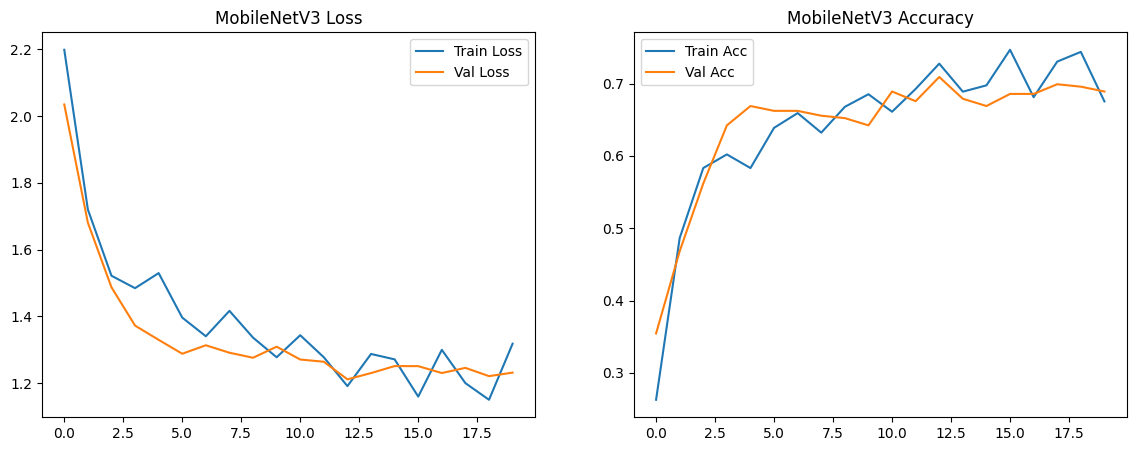


--- Training ResNeXt-50 ---
Epoch 1/30 | Train Loss: 2.1394 Acc: 0.3059 | Val Loss: 1.6392 Acc: 0.5385
Epoch 2/30 | Train Loss: 1.6403 Acc: 0.5298 | Val Loss: 1.4068 Acc: 0.6221
Epoch 3/30 | Train Loss: 1.3379 Acc: 0.6632 | Val Loss: 1.3318 Acc: 0.6154
Epoch 4/30 | Train Loss: 1.3068 Acc: 0.6733 | Val Loss: 1.2718 Acc: 0.6421
Epoch 5/30 | Train Loss: 1.2873 Acc: 0.6731 | Val Loss: 1.2690 Acc: 0.6756
Epoch 6/30 | Train Loss: 1.3295 Acc: 0.6641 | Val Loss: 1.3005 Acc: 0.6656
Epoch 7/30 | Train Loss: 1.2251 Acc: 0.7105 | Val Loss: 1.2250 Acc: 0.6957
Epoch 8/30 | Train Loss: 1.1231 Acc: 0.7523 | Val Loss: 1.2402 Acc: 0.6890
Epoch 9/30 | Train Loss: 1.1079 Acc: 0.7639 | Val Loss: 1.2705 Acc: 0.6689
Epoch 10/30 | Train Loss: 1.1170 Acc: 0.7545 | Val Loss: 1.2100 Acc: 0.6856
Epoch 11/30 | Train Loss: 1.1356 Acc: 0.7470 | Val Loss: 1.2078 Acc: 0.7291
Epoch 12/30 | Train Loss: 1.1096 Acc: 0.7593 | Val Loss: 1.2113 Acc: 0.7124
Epoch 13/30 | Train Loss: 1.1241 Acc: 0.7516 | Val Loss: 1.2310 Acc:

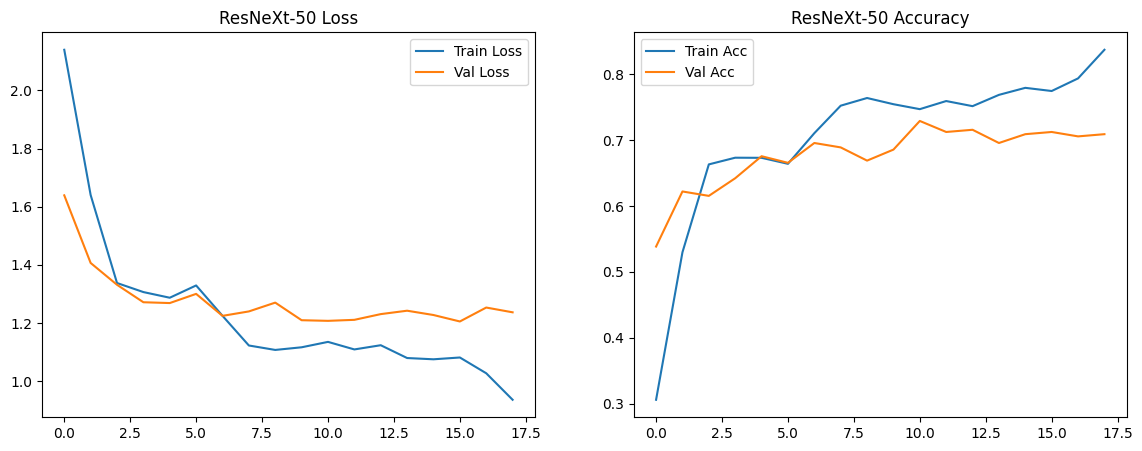


--- Training EfficientNet-B3 ---
Epoch 1/30 | Train Loss: 2.3172 Acc: 0.2101 | Val Loss: 2.1482 Acc: 0.3512
Epoch 2/30 | Train Loss: 2.0104 Acc: 0.3917 | Val Loss: 1.7396 Acc: 0.4849
Epoch 3/30 | Train Loss: 1.8139 Acc: 0.4516 | Val Loss: 1.5746 Acc: 0.5217
Epoch 4/30 | Train Loss: 1.5763 Acc: 0.5653 | Val Loss: 1.4614 Acc: 0.5686
Epoch 5/30 | Train Loss: 1.5250 Acc: 0.5804 | Val Loss: 1.4490 Acc: 0.5853
Epoch 6/30 | Train Loss: 1.5007 Acc: 0.5862 | Val Loss: 1.3596 Acc: 0.6421
Epoch 7/30 | Train Loss: 1.4106 Acc: 0.6331 | Val Loss: 1.3218 Acc: 0.6355
Epoch 8/30 | Train Loss: 1.4018 Acc: 0.6504 | Val Loss: 1.2688 Acc: 0.6589
Epoch 9/30 | Train Loss: 1.3727 Acc: 0.6426 | Val Loss: 1.2895 Acc: 0.6555
Epoch 10/30 | Train Loss: 1.3417 Acc: 0.6671 | Val Loss: 1.2670 Acc: 0.6722
Epoch 11/30 | Train Loss: 1.2961 Acc: 0.6812 | Val Loss: 1.2588 Acc: 0.6856
Epoch 12/30 | Train Loss: 1.2808 Acc: 0.6794 | Val Loss: 1.2787 Acc: 0.6856
Epoch 13/30 | Train Loss: 1.2667 Acc: 0.6952 | Val Loss: 1.2613

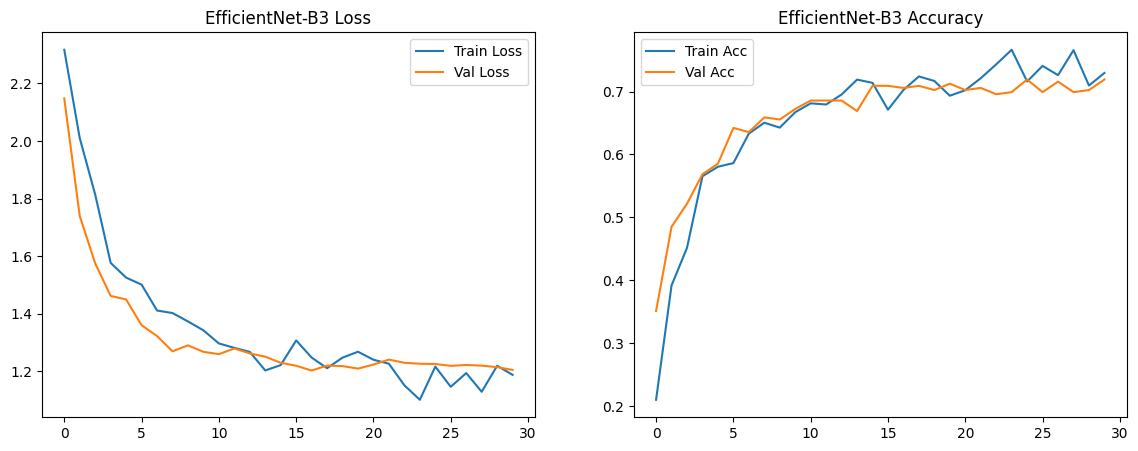

In [7]:
NUM_CLASSES = len(class_names) if class_names else 11

# MobileNetV3
print("Initializing MobileNetV3...")
mobilenet = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
mobilenet.classifier[3] = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(mobilenet.classifier[3].in_features, NUM_CLASSES)
)
print(f"MobileNet Trainable Params: {sum(p.numel() for p in mobilenet.parameters() if p.requires_grad):,}")

# ResNeXt-50
print("Initializing ResNeXt-50...")
resnext = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.DEFAULT)
resnext.fc = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(resnext.fc.in_features, NUM_CLASSES)
)
print(f"ResNeXt-50 Trainable Params: {sum(p.numel() for p in resnext.parameters() if p.requires_grad):,}")

# EfficientNet-B3
print("Initializing EfficientNet-B3...")
efficientnet = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.DEFAULT)
efficientnet.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features=1536, out_features=NUM_CLASSES)
)
print(f"EfficientNet-B3 Trainable Params: {sum(p.numel() for p in efficientnet.parameters() if p.requires_grad):,}")

# Set FLAG to True to trigger the 30 epoch loops
RUN_TRAINING = True

models_dict = {
    'MobileNetV3': mobilenet,
    'ResNeXt-50': resnext,
    'EfficientNet-B3': efficientnet
}

if RUN_TRAINING and train_loader is not None:
    for name, model in models_dict.items():
        trained_model, hist = train_model(model, name, train_loader, val_loader, EPOCHS)
        models_dict[name] = trained_model
        plot_history(hist, name)


## 7.Evaluation & Comparison
Reports accuracy, precision, recall, F1 (macro & weighted), and plots confusion matrix.

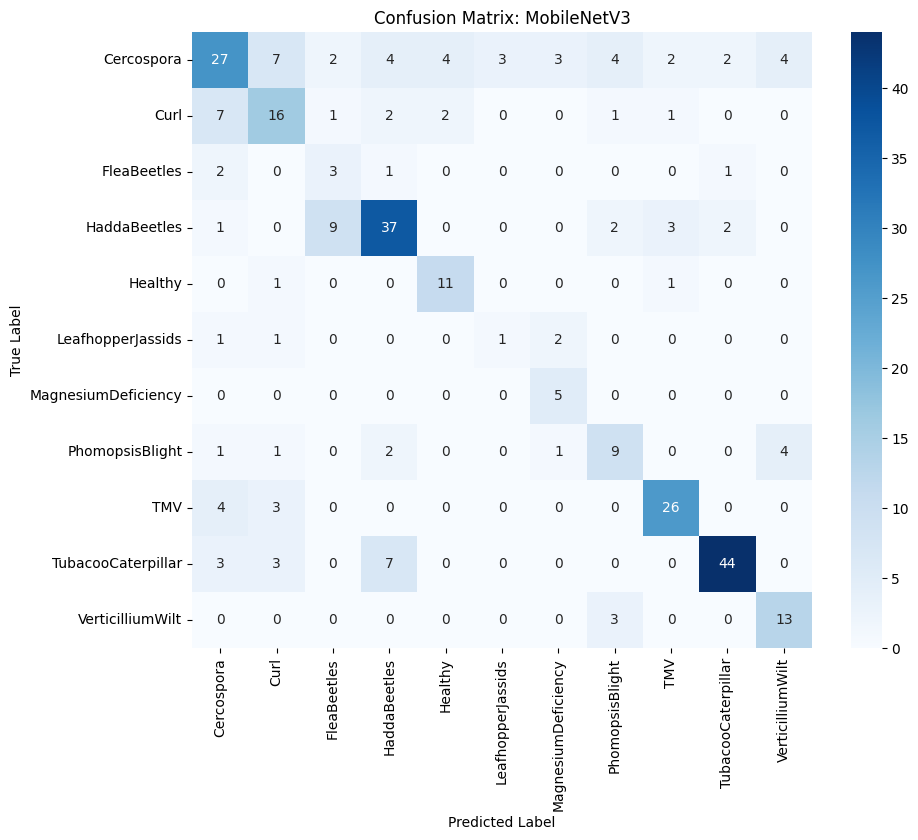

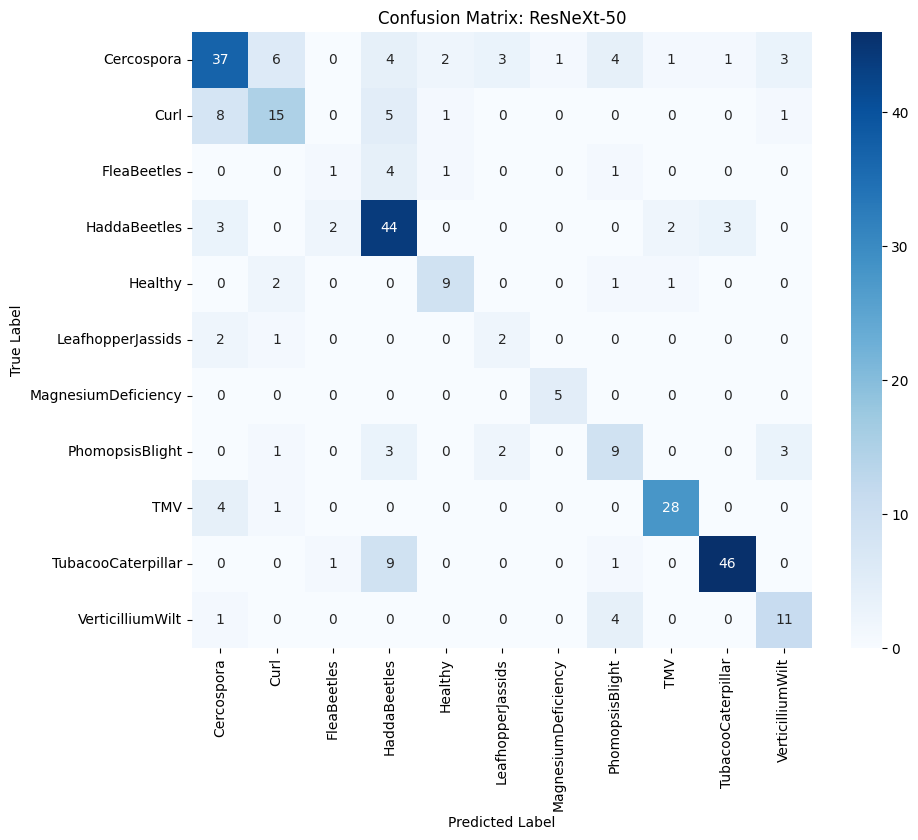

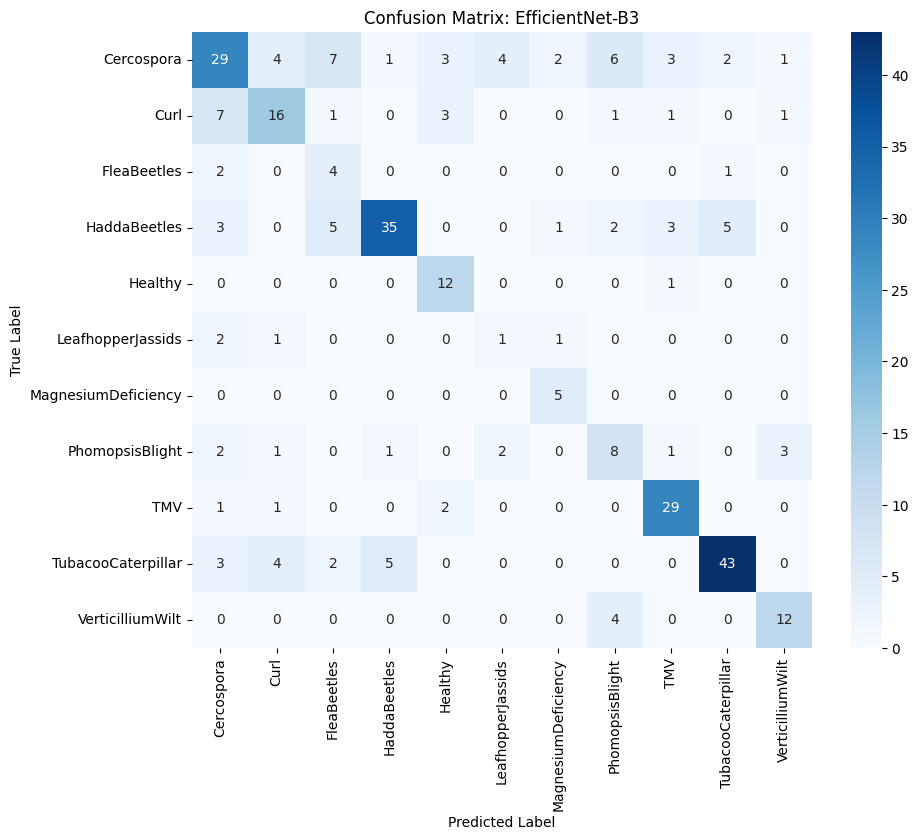

,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro),F1-Score (Weighted),Inference Time (s/batch)
0,MobileNetV3,0.640000,0.555931,0.636458,0.578932,0.642763,0.269341
1,ResNeXt-50,0.690000,0.618618,0.635432,0.622026,0.689078,0.208226
2,EfficientNet-B3,0.646667,0.565439,0.651941,0.589067,0.653314,0.135242


In [8]:
def evaluate_model(model, test_loader, name):
    model.eval()
    y_true = []
    y_pred = []
    start_time = time.time()
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            outputs = model(inputs.to(device))
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            
    inference_time = (time.time() - start_time) / len(test_loader)
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    return {
        'Model': name,
        'Accuracy': acc,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1-Score (Macro)': f1_macro,
        'F1-Score (Weighted)': f1_weighted,
        'Inference Time (s/batch)': inference_time
    }

if RUN_TRAINING and test_loader is not None:
    df_results = pd.DataFrame([evaluate_model(m, test_loader, n) for n, m in models_dict.items()])
    display(df_results)


## 8.Robustness Analysis
Models are tested against distribution shifts (Additive Gaussian Noise)

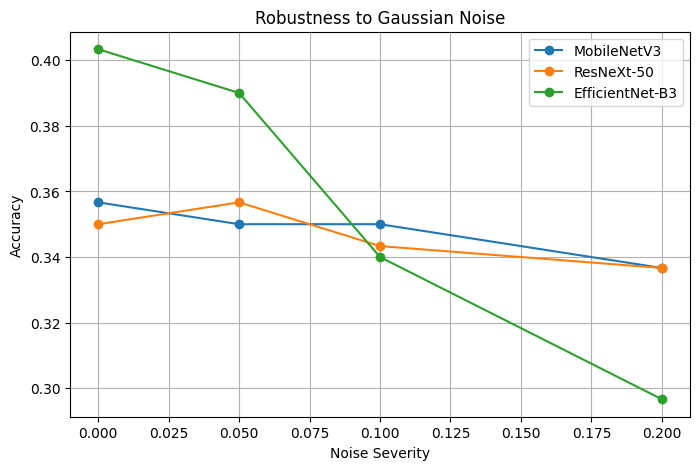

In [9]:
def add_gaussian_noise(image, severity):
    noise = torch.randn_like(image) * severity
    return torch.clamp(image + noise, 0, 1)

def eval_robustness(model, test_loader, severity=0.1):
    model.eval()
    corrects = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            corrupted_inputs = add_gaussian_noise(inputs, severity)
            outputs = model(corrupted_inputs)
            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels.data)
            total += inputs.size(0)
    return (corrects.double() / total).item()

if RUN_TRAINING and test_loader is not None:
    severities = [0.0, 0.05, 0.1, 0.2]
    robustness_results = {'Severity': severities}
    
    for name, model in models_dict.items():
        acc_drop = []
        for s in severities:
            acc_drop.append(eval_robustness(model, test_loader, severity=s))
        robustness_results[name] = acc_drop
        
    df_robust = pd.DataFrame(robustness_results)
    plt.figure(figsize=(8, 5))
    for name in models_dict.keys():
        plt.plot(df_robust['Severity'], df_robust[name], marker='o', label=name)
    plt.title('Robustness to Gaussian Noise')
    plt.xlabel('Noise Severity')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


## 9.Error Analysis
Identifying Top-K Misclassifications with highest confidence scores from the Best Model.

Top 5 High-Confidence Misclassifications for ResNeXt-50:


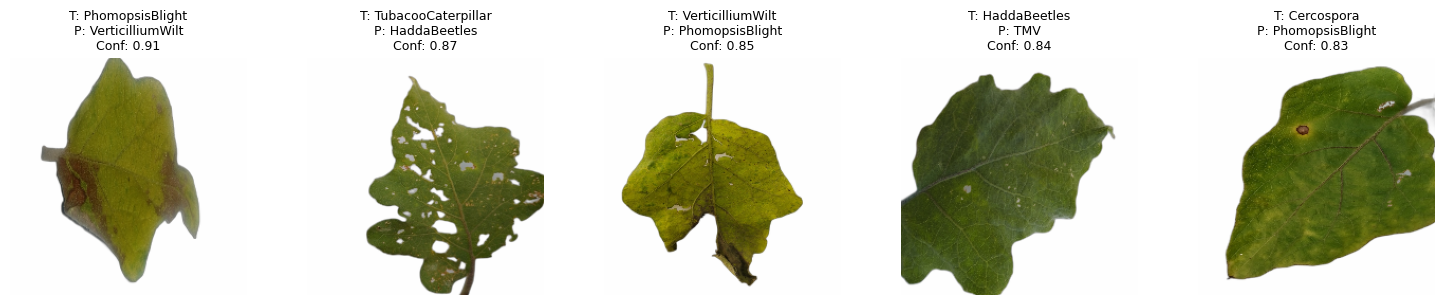

In [10]:
import torch.nn.functional as F

def error_analysis(model, test_loader, name, top_k=5):
    model.eval()
    misclassified = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            probs = F.softmax(model(inputs), dim=1)
            confidences, preds = torch.max(probs, 1)
            
            for i in range(inputs.size(0)):
                if preds[i] != labels[i]:
                    misclassified.append({
                        'image': inputs[i].cpu(),
                        'true_label': labels[i].item(),
                        'pred_label': preds[i].item(),
                        'confidence': confidences[i].item()
                    })
                    
    misclassified = sorted(misclassified, key=lambda x: x['confidence'], reverse=True)
    
    print(f"Top {top_k} High-Confidence Misclassifications for {name}:")
    fig, axes = plt.subplots(1, top_k, figsize=(15, 3))
    if top_k == 1: axes = [axes]
    
    for idx, item in enumerate(misclassified[:top_k]):
        img = item['image'].permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        axes[idx].imshow(img)
        t_label = class_names[item['true_label']] if class_names else item['true_label']
        p_label = class_names[item['pred_label']] if class_names else item['pred_label']
        
        axes[idx].set_title(f"T: {t_label}\nP: {p_label}\nConf: {item['confidence']:.2f}", fontsize=9)
        axes[idx].axis('off')
    plt.tight_layout()
    plt.show()

if RUN_TRAINING and test_loader is not None:
    error_analysis(models_dict['ResNeXt-50'], test_loader, 'ResNeXt-50', top_k=5)
